In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import os


os.chdir("/home/philbou/projects/def-rfajber/philbou/analysis_paper1")

import diagnostic_plot_helper as dps  

path_cur = "/home/philbou/projects/def-rfajber/philbou/analysis_paper1/Figures"

plt.rcParams['text.usetex'] = True

def decomp_term_time_2D_vert(term,area,phalf,ps):
    # term is (time,pfull,lat,lon)
    vert_avg = dps.vertical_int(term, phalf,ps) # (time,lat,lon)
    vert_2D_avg = dps.area_w_avg(area, vert_avg, D3=True) # (time)
    time_vert_2D_avg = np.mean(vert_2D_avg,axis = 0)
    
    prime = term - time_vert_2D_avg
    return term,time_vert_2D_avg,prime

def decomp_term_time_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    prime = term - time_2D_avg
    return term,time_2D_avg,prime
    
def get_global_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=True) # (time)
    time_2D_avg = np.mean(twoD_avg,axis = 0)
    return time_2D_avg

def get_global(term,area,phalf,ps):
     # term is (time,pfull,lat,lon)
    vert_avg = dps.vertical_int(term, phalf,ps) # (time,lat,lon)
    vert_2D_avg = dps.area_w_avg(area, vert_avg, D3=True) # (time)
    time_vert_2D_avg = np.mean(vert_2D_avg,axis = 0)
    return time_vert_2D_avg

def decomp_term_2D(term,area):
    # term is (time,lat,lon)
    twoD_avg = dps.area_w_avg(area, term, D3=False) # (time)    
    prime = term - twoD_avg
    return term,twoD_avg,prime
    

def age_decomposition_terms(ds_age,ds_6h,ds_dyn):
    area = dps.get_area(ds_age)
    phalf = 100*ds_age.phalf.values
    ps = ds_age.ps.mean(dim = "time").values
    bk = ds_dyn.bk.mean(dim = "time").values
    g = 9.81 # m/s^2 # kg/m^2
    q = ds_age.sphum.values # kg/kg
    col_air_ = dps.vertical_int(np.ones_like(q),phalf,ps)
    col_air = np.mean(col_air_,axis = 0)
    # a = <{a}> + a'
    # A = {a}
    # A = <A> + A"

    # Source term
    S =  ds_age.dt_qg_condensation.values + ds_age.dt_qg_convection.values
    S, global_S, S_prime = decomp_term_time_2D_vert(S,area,phalf,ps)
    vert_S = dps.vertical_int(S,phalf,ps) # (time,lat,lon)
    
    # Sink term
    Sminus = ds_age.dt_sink.values # (time,pfull,lat,lon)
    Sminus, global_Sminus, Sminus_prime = decomp_term_time_2D_vert(Sminus,area,phalf,ps)
    vert_Sminus = dps.vertical_int(Sminus,phalf,ps) # (time,lat,lon)
    
    #Positive source term
    vert_Splus =  dps.vertical_int(S,phalf,ps) - dps.vertical_int(Sminus,phalf,ps)
    vert_Splus_, global_Splus, Splus_prime = decomp_term_time_2D(vert_Splus,area)
    
    # Precipitation
    P = ds_age.precipitation.values  # kg/m/m/s / kg/m^2 = kg/kg/s # (time,lat,lon)
    da = ds_6h.precip_age
    masked = da.where(da != 0)
    precip_age = masked.mean(dim="time", skipna=True).values
    time_vert_2D_avg_precip_age = dps.area_w_avg(area, precip_age, D3=False) # (time)
    
    Pstar = -vert_Sminus - P
    P, global_P, P_prime = decomp_term_time_2D(P,area)
    Pstar, global_Pstar, Pstar_prime = decomp_term_time_2D(Pstar,area)
    # Lambda = qT
    qT = ds_age.sphum_age_1.values # s kg/kg
    vert_qT = dps.vertical_int(qT,phalf,ps)
    vert_qT, global_qT, qT_prime = decomp_term_time_2D(vert_qT,area)

    # q
    
    q, global_q, q_prime = decomp_term_time_2D_vert(q,area,phalf,ps)

    # W
    W = dps.vertical_int(q, phalf,ps) # (time,lat,lon)
    W, global_W, W_prime = decomp_term_time_2D(W,area)
   
    # depletion
    dep = np.mean(W,axis = 0)/np.mean(P, axis = 0)
    dep, global_dep, dep_prime = decomp_term_2D(dep,area)
    
    # Calculate terms
    
    # <W>/<P>
    term_0_0 = global_W/global_P
    
    # <W/P>
    term_0 = global_dep
        
    # <W'/P'> = <W/P> - <W>/<P>
    term_0_1 = term_0 - term_0_0
    
    # <{qT}>/<W>
    term_1 = global_qT / global_q
    
    den = global_q * global_P
    
    # <P*><{qT}> /(<W><P>)
    term_2_1 = (global_Pstar * global_qT) / den
    
    # -<{S-' qT'}> /(<W><P>)
    tmp_2_4 = Sminus_prime #* qT_prime
    n, term_2_4_, m = decomp_term_time_2D_vert(tmp_2_4,area,phalf,ps)
    term_2_4 = -term_2_4_/den
    
    # -<{S' qT'}> /(<W><P>)
    tmp_2_3 = S_prime #* qT_prime
    n, term_2_3_, m = decomp_term_time_2D_vert(tmp_2_3,area,phalf,ps)
    term_2_3 = -term_2_3_/den
    
    # -<{q'^2}> /(<W><P>)
    var_q = q_prime*q_prime
    n, term_2_5_, m = decomp_term_time_2D_vert(var_q,area,phalf,ps)
    term_2_5 = -term_2_5_/den
    
    # - <{S}><{qT}> /(<W><P>)
    term_2_2 = -(global_S * global_qT)/den   
    
    # - <{S+}><{qT}> /(<W><P>)
    term_2_6 = - (global_Splus * global_qT)/den  

    # -<{S+' qT'}> /(<W><P>)
    tmp_2_7 = Splus_prime[:,np.newaxis,:,:] #* qT_prime
    n, term_2_7_, m = decomp_term_time_2D_vert(tmp_2_7,area,phalf,ps)
    term_2_7 = -term_2_7_/den
    
    SminusqT ,global_SminusqT, SminusqT_prime = decomp_term_time_2D_vert(Sminus * qT,area,phalf,ps)
    SplusqT ,global_SplusqT, SplusqT_prime = decomp_term_time_2D_vert(vert_Splus[:,np.newaxis,:,:] * qT,area,phalf,ps)
    # error 
    global_q2 = get_global(q**2,area,phalf,ps)
    err = (global_q2 + 2*global_SminusqT + global_SplusqT)
    
    term_2a = term_2_1 + term_2_3 +term_2_4  +term_2_5 
    
    term_1b = 2*term_1
    
    term_2b = 2*term_2_1+  term_2_5 + 2*term_2_4 + term_2_6 +term_2_7 #+ err/den
        
    terms_dict = {
        '0.0': term_0_0,
        '0.1': term_0_1,
        '0': term_0,
        '1a': term_1,
        '1b': term_1b,
        '2a': term_2a,
        '2b': term_2b,
        '2.1': term_2_1,
        '2.2': term_2_2,
        '2.3': term_2_3,
        '2.4': term_2_4,
        '2.5': term_2_5,
        '2.6': term_2_6,
        '2.7': term_2_7,
        'precip': time_vert_2D_avg_precip_age,
    }

    return terms_dict


def select_region3D(ds, lat_range, lon_range, pfull_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1]),
        pfull=slice(pfull_range[0], pfull_range[1]),
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region

def select_vertical(ds, pfull_range):
    region = ds.sel(
        pfull=slice(pfull_range[0], pfull_range[1]),
        phalf=slice(pfull_range[0], pfull_range[1])
    )
    return region

def select_region2D(ds, lat_range, lon_range):
    region = ds.sel(
        lat=slice(lat_range[0], lat_range[1]),
        lon=slice(lon_range[0], lon_range[1])
    )
    return region
def main_hyd(delta_sst_values = np.arange(-4, 5, 1),lat_range = (-90,90),
             lon_range = (0, 360), pfull_range = (0, 1000)):
    print(delta_sst_values)
    ds_dict = {}
    for delta_sst in delta_sst_values:
        path_folder = "/home/philbou/projects/def-rfajber/philbou/saved_ds"
        base_folder_name = "RT42_sst_"
        exp_folder_name = f"{base_folder_name}{'m' + str(abs(delta_sst)) if delta_sst < 0 else str(delta_sst)}_bucket"
        #exp_folder_name = "RT42_sst_0_test"
        path = f"{path_folder}/{exp_folder_name}"
        if abs(delta_sst) == 4 or abs(delta_sst) == 3 or abs(delta_sst) == 1:
            e = ""
        else: e = "_"
        ds_age_ = xr.open_dataset(f"{path}/age.nc")
        ds_6h_ = xr.open_dataset(f"{path}/data_6h.nc")
        ds_pa_ = xr.open_dataset(f"{path}/precipitation_age.nc")

        ds_dyn_ = xr.open_dataset(f"{path}/dynamics.nc",decode_times=False)
        ds_mix_ = xr.open_dataset(f"{path}/mixed_layer.nc",decode_times=False)
        
        ds_age = select_region3D(ds_age_, lat_range, lon_range, pfull_range)    
        ds_6h = select_region3D(ds_6h_, lat_range, lon_range, pfull_range) 
        ds_pa = select_region2D(ds_pa_, lat_range, lon_range) 
        ds_mix = select_region2D(ds_mix_, lat_range, lon_range)
        ds_dyn = select_region3D(ds_dyn_, lat_range, lon_range,pfull_range)

        area = dps.get_area(ds_age)
        ts = ds_mix.t_surf.values
        time_global_ts = dps.area_w_avg(area,np.mean(ts, axis=0))
        terms_dict = age_decomposition_terms(ds_age,ds_pa,ds_dyn)
        
        tmp_dic = {
            'delta_sst_model': delta_sst,
            'ds_age': ds_age,
            'global_surf_temp': time_global_ts,
            'decomp_terms': terms_dict
        }
        ds_dict[str(delta_sst)] = tmp_dic

    # Prepare arrays for plotting
    N = len(delta_sst_values)
    delta_sst_exact = np.zeros(N)
    sst_exact = np.zeros(N)

    term_0_0_arr = np.zeros(N)
    term_0_1_arr = np.zeros(N)
    term_0_arr = np.zeros(N)
    term_1a_arr = np.zeros(N)
    term_1b_arr = np.zeros(N)
    term_2a_arr = np.zeros(N)
    term_2b_arr = np.zeros(N)
    term_2_1_arr = np.zeros(N)
    term_2_2_arr = np.zeros(N)
    term_2_3_arr = np.zeros(N)
    term_2_4_arr = np.zeros(N)
    term_2_5_arr = np.zeros(N)
    term_2_6_arr = np.zeros(N)
    term_2_7_arr = np.zeros(N)
    term_precip_arr = np.zeros(N)

    control_sst_val = ds_dict['0']['delta_sst_model']

    for i, delta_sst in enumerate(delta_sst_values):
        tmp_dict = ds_dict[str(delta_sst)]
        dT_exact = tmp_dict['delta_sst_model'] - control_sst_val
        delta_sst_exact[i] = dT_exact
        terms_dict = tmp_dict['decomp_terms']
        term_0_0_arr[i] = terms_dict['0.0']
        term_0_1_arr[i] = terms_dict['0.1']
        term_0_arr[i] = terms_dict['0']
        term_1a_arr[i] = terms_dict['1a']
        term_1b_arr[i] = terms_dict['1b']
        term_2a_arr[i] = terms_dict['2a']
        term_2b_arr[i] = terms_dict['2b']
        term_2_1_arr[i] = terms_dict['2.1']
        term_2_2_arr[i] = terms_dict['2.2']
        term_2_3_arr[i] = terms_dict['2.3']
        term_2_4_arr[i] = terms_dict['2.4']
        term_2_5_arr[i] = terms_dict['2.5']
        term_2_6_arr[i] = terms_dict['2.6']
        term_2_7_arr[i] = terms_dict['2.7']
        term_precip_arr[i] = terms_dict['precip']
        sst_exact[i] = tmp_dict['global_surf_temp']
    terms_arr_dict = {}
    terms_arr_dict['0.0'] = term_0_0_arr
    terms_arr_dict['0.1'] = term_0_1_arr
    terms_arr_dict['0'] = term_0_arr
    terms_arr_dict['1a'] = term_1a_arr
    terms_arr_dict['1b'] = term_1b_arr
    terms_arr_dict['2a'] = term_2a_arr
    terms_arr_dict['2b'] = term_2b_arr
    terms_arr_dict['2.1'] = term_2_1_arr
    terms_arr_dict['2.2'] = term_2_2_arr
    terms_arr_dict['2.3'] = term_2_3_arr
    terms_arr_dict['2.4'] = term_2_4_arr
    terms_arr_dict['2.5'] = term_2_5_arr
    terms_arr_dict['2.6'] = term_2_6_arr
    terms_arr_dict['2.7'] = term_2_7_arr
    terms_arr_dict['precip'] = term_precip_arr

    return sst_exact, terms_arr_dict

In [12]:
def get_frac_rate(T,val):
    dT = np.gradient(T)
    dval = np.gradient(val)
    frac_rate = dval/dT * (1/val)
    return np.mean(frac_rate)

sst_exact2, terms_dict_tropical = main_hyd(lat_range = (-30,30),pfull_range = (0, 1000),delta_sst_values = [-4,-3,-2,-1,1,2,3,4])

term_0_0_arr_tropical = terms_dict_tropical['0.0']
term_1a_arr_tropical = terms_dict_tropical['1a']
term_precip_arr_tropical = terms_dict_tropical['precip']

sst_exact1, terms_dict_tropical_trop = main_hyd(lat_range = (-30,30),pfull_range = (200, 1000),delta_sst_values = [-4,-3,-2,-1,1,2,3,4])
term_0_0_arr_tropical_trop = terms_dict_tropical_trop['0.0']
term_1a_arr_tropical_trop = terms_dict_tropical_trop['1a']
term_precip_arr_tropical_trop = terms_dict_tropical_trop['precip']

sst_exact, terms_dict = main_hyd(delta_sst_values = [-4,-3,-2,-1,1,2,3,4])
term_0_0_arr = terms_dict['0.0']
term_1a_arr = terms_dict['1a']
term_precip_arr = terms_dict['precip']

WP_frac_tropical = get_frac_rate(sst_exact2,term_0_0_arr_tropical)
qT_frac_tropical = get_frac_rate(sst_exact2,term_1a_arr_tropical)
precip_frac_tropical = get_frac_rate(sst_exact2,term_precip_arr_tropical)

WP_frac_tropical_trop = get_frac_rate(sst_exact1,term_0_0_arr_tropical_trop)
qT_frac_tropical_trop = get_frac_rate(sst_exact1,term_1a_arr_tropical_trop)
precip_frac_tropical_trop = get_frac_rate(sst_exact1,term_precip_arr_tropical_trop)

WP_frac = get_frac_rate(sst_exact,term_0_0_arr)
qT_frac = get_frac_rate(sst_exact,term_1a_arr)
precip_frac = get_frac_rate(sst_exact,term_precip_arr)



[-4, -3, -2, -1, 1, 2, 3, 4]
[-4, -3, -2, -1, 1, 2, 3, 4]
[-4, -3, -2, -1, 1, 2, 3, 4]


In [16]:
sst_exact_ = np.insert(sst_exact,4, sst_exact[3] + 1)
sst_exact2_ = np.insert(sst_exact2,4, sst_exact2[3] + 1)

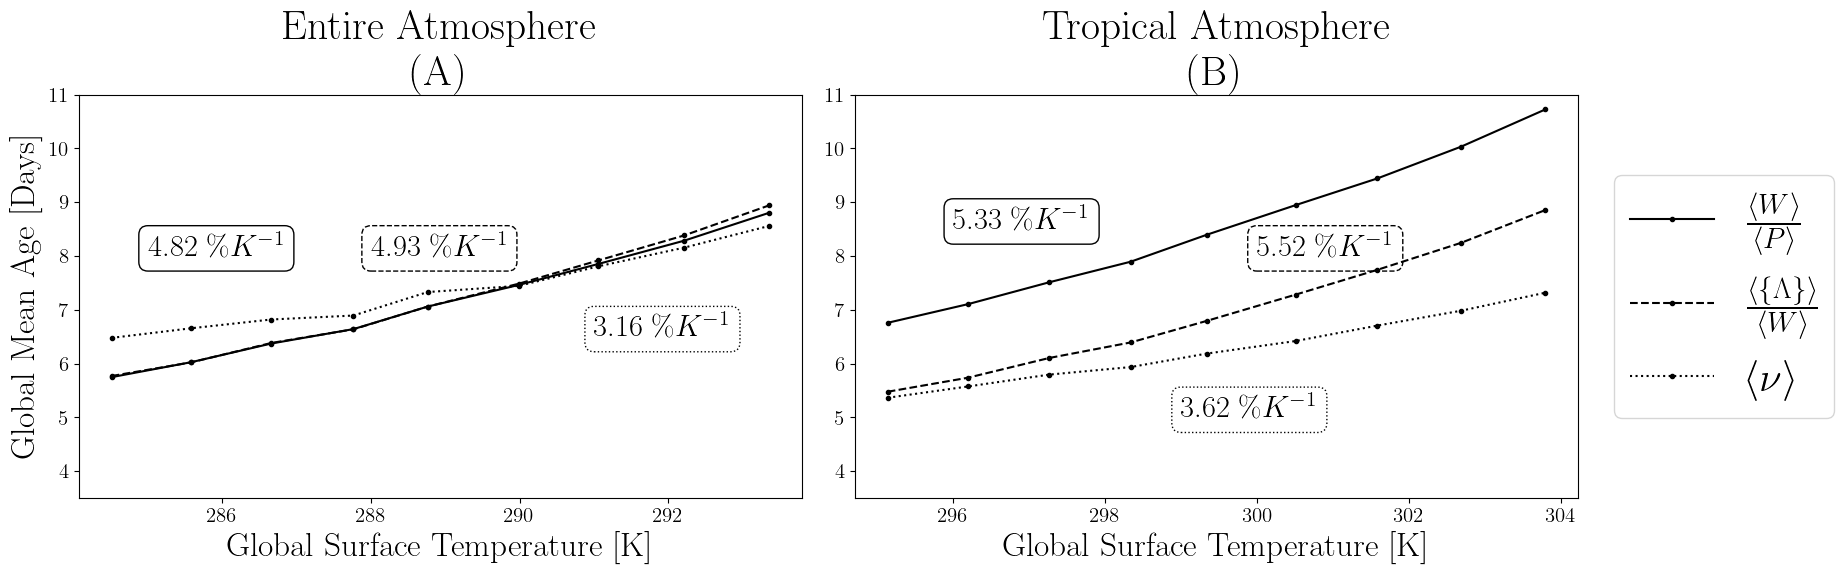

In [45]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

fig,axs = plt.subplots(1,2,figsize=(22, 6))  # Width x Height

ax1 = axs[0]

ax1.plot(sst_exact_,np.insert(term_0_0_arr, 4, 7.06*24*60**2)/(24*60**2),label = r"$\frac{\langle W \rangle}{\langle P \rangle}$",linestyle = "solid",color = "black",marker = ".")
ax1.plot(sst_exact_,np.insert(term_1a_arr, 4, 7.06*24*60**2)/(24*60**2),label = r"$\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",linestyle = "dashed",color = "black",marker = ".")
ax1.plot(sst_exact_,np.insert(term_precip_arr, 4, 7.33*24*60**2)/(24*60**2),label = r"$\langle \nu \rangle$",linestyle = "dotted",color = "black",marker = ".")

ax1.text(
    285, 8,
    r"4.82 $\% K^{-1}$",
    color="black",
    fontweight="extra bold",
    fontsize=22,
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor="black",
        facecolor="none",
        linestyle="solid"
    )
)

ax1.text(
    288, 8,
    r"4.93 $\% K^{-1}$",
    color="black",
    fontweight="extra bold",
    fontsize=22,
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor="black",
        facecolor="none",
        linestyle="dashed"
    )
)

ax1.text(
    291, 6.5,
    r"3.16 $\% K^{-1}$",
    color="black",
    fontweight="extra bold",
    fontsize=22,
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor="black",
        facecolor="none",
        linestyle="dotted"
    )
)

ax1.set_ylabel("Global Mean Age [Days]",fontsize = 24)
ax1.set_xlabel("Global Surface Temperature [K]",fontsize = 24)
ax1.set_title("Entire Atmosphere\n (A)",fontsize = 30)


ax1 = axs[1]

ax1.plot(sst_exact2_,np.insert(term_0_0_arr_tropical, 4, term_0_0_arr_tropical[3]+0.5*24*60**2)/(24*60**2),label = r"$\frac{\langle W \rangle}{\langle P \rangle}$",linestyle = "solid",color = "black",marker = ".")
ax1.plot(sst_exact2_,np.insert(term_1a_arr_tropical, 4, term_1a_arr_tropical[3]+0.4*24*60**2)/(24*60**2),label = r"$\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",linestyle = "dashed",color = "black",marker = ".")
ax1.plot(sst_exact2_,np.insert(term_precip_arr_tropical, 4, term_precip_arr_tropical[3]+0.25*24*60**2)/(24*60**2),label = r"$\langle \nu \rangle$",linestyle = "dotted",color = "black",marker = ".")


ax1.text(
    296, 8.5,
    r"5.33 $\% K^{-1}$",
    color="black",
    fontweight="extra bold",
    fontsize=22,
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor="black",
        facecolor="none",
        linestyle="solid"
    )
)

ax1.text(
    300, 8,
    r"5.52 $\% K^{-1}$",
    color="black",
    fontweight="extra bold",
    fontsize=22,
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor="black",
        facecolor="none",
        linestyle="dashed"
    )
)

ax1.text(
    299, 5,
    r"3.62 $\% K^{-1}$",
    color="black",
    fontweight="extra bold",
    fontsize=22,
    bbox=dict(
        boxstyle="round,pad=0.3",
        edgecolor="black",
        facecolor="none",
        linestyle="dotted"
    )
)


ax1.set_xlabel("Global Surface Temperature [K]",fontsize = 24)
ax1.set_title("Tropical Atmosphere\n (B)",fontsize = 30)



for i in range(2):
    axs[i].set_ylim(3.5,11)



plt.legend(loc='center left',           # Aligns the legend vertically centered to the left of the bbox
    bbox_to_anchor=(1.02, 0.5),  # Pushes it completely outside the plot area
    ncol=1,                      # Makes it vertical
    frameon=True,               # Optional: keeps the legend frame
    fontsize=30                 # Optional: adjust font size if needed
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leaves space on the right for the legend

plt.savefig(f"{path_cur}/f08.png",bbox_inches = "tight",dpi = 250)

In [ ]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

fig,axs = plt.subplots(1,1,figsize=(8, 6))  # Width x Height

ax1 = axs
tmp = term_precip_arr/(24*60**2)


#ax1.plot(sst_exact,term_0_0_arr/(24*60**2),label = r"$\langle WVRT \rangle$",color = "green",marker = ".")
ax1.plot(sst_exact,term_1a_arr/(24*60**2),label = r"WVRT",color = "mediumblue",marker = ".")
#ax1.plot(sst_exact,term_1b_arr/(24*60**2),label = r"[1b] =  $2\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",color = "mediumblue",marker = ".",linestyle = "dashed")
ax1.plot(sst_exact,tmp,label = r"Age Precip",color = "mediumorchid",marker = ".")

#ax1.text(296-10, 8, f"{round(100*WP_frac,2)}" + r" $\% K^{-1}$", color="green", fontweight="extra bold",fontsize = 22)
tmp_frac = get_frac_rate(sst_exact,tmp)
ax1.text(299-10, 6.5, f"{round(100*tmp_frac,2)}" + r" $\% K^{-1}$", color="mediumorchid", fontweight="extra bold",fontsize = 30)

ax1.text(299-14, 8, f"{round(100*qT_frac,2)}" + r" $\% K^{-1}$", color="mediumblue", fontweight="extra bold",fontsize = 30)

ax1.set_ylabel("Residence Time [Days]",fontsize = 24)
ax1.set_xlabel("Global Surface Temperature [K]",fontsize = 24)




axs.set_ylim(4,9.5)

ax1.legend(fontsize = 22, loc = "lower right")

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leaves space on the right for the legend

plt.savefig(f"{path_cur}/WP_vs_Lambda_BRACE.png",bbox_inches = "tight",dpi = 250)

In [ ]:
tmp

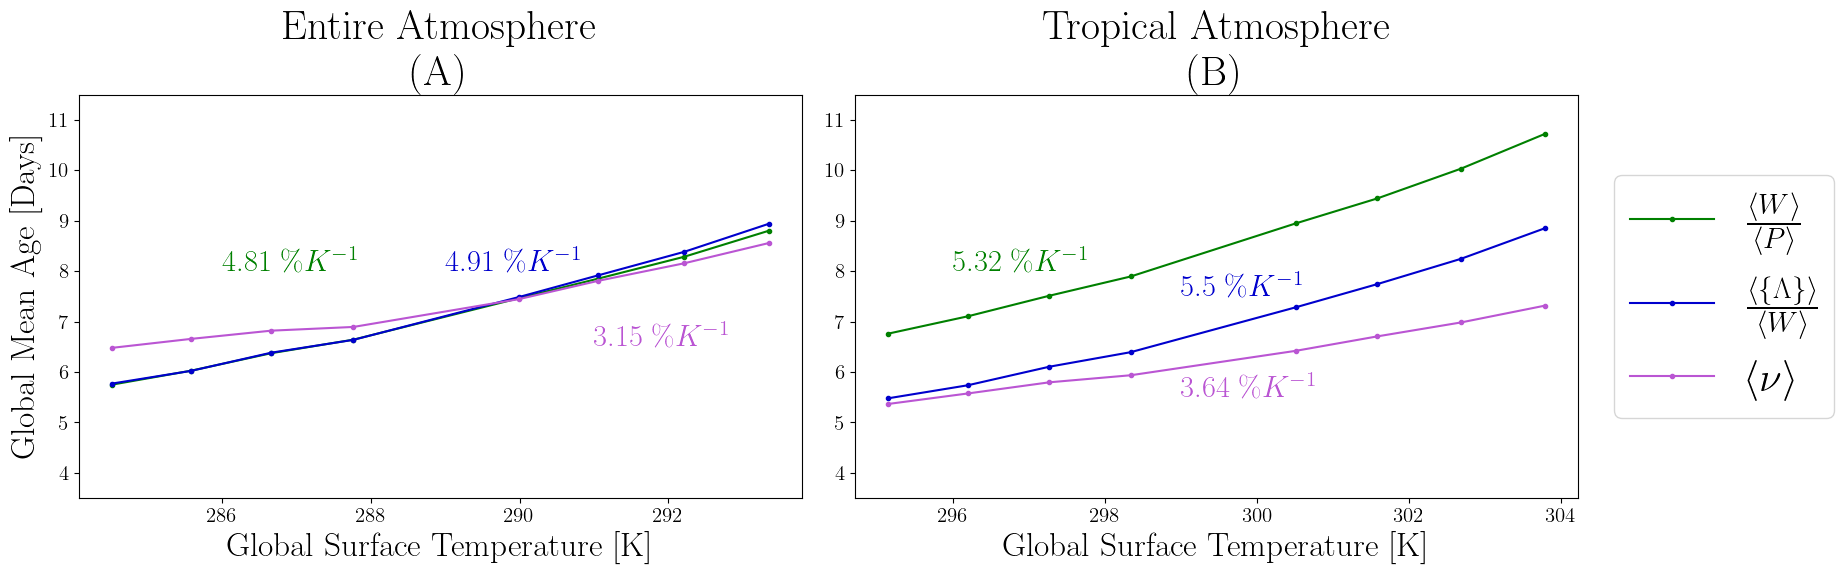

In [8]:
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

fig,axs = plt.subplots(1,2,figsize=(22, 6))  # Width x Height

ax1 = axs[0]

ax1.plot(sst_exact,term_0_0_arr/(24*60**2),label = r"$\frac{\langle W \rangle}{\langle P \rangle}$",color = "green",marker = ".")
ax1.plot(sst_exact,term_1a_arr/(24*60**2),label = r"$\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",color = "mediumblue",marker = ".")
#ax1.plot(sst_exact,term_1b_arr/(24*60**2),label = r"[1b] =  $2\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",color = "mediumblue",marker = ".",linestyle = "dashed")
ax1.plot(sst_exact,term_precip_arr/(24*60**2),label = r"$\langle \nu \rangle$",color = "mediumorchid",marker = ".")

ax1.text(296-10, 8, f"{round(100*WP_frac,2)}" + r" $\% K^{-1}$", color="green", fontweight="extra bold",fontsize = 22)

ax1.text(299-8, 6.5, f"{round(100*precip_frac,2)}" + r" $\% K^{-1}$", color="mediumorchid", fontweight="extra bold",fontsize = 22)

ax1.text(299-10, 8, f"{round(100*qT_frac,2)}" + r" $\% K^{-1}$", color="mediumblue", fontweight="extra bold",fontsize = 22)

ax1.set_ylabel("Global Mean Age [Days]",fontsize = 24)
ax1.set_xlabel("Global Surface Temperature [K]",fontsize = 24)
ax1.set_title("Entire Atmosphere\n (A)",fontsize = 30)


ax1 = axs[1]

ax1.plot(sst_exact2,term_0_0_arr_tropical/(24*60**2),label = r"$\frac{\langle W \rangle}{\langle P \rangle}$",color = "green",marker = ".")
ax1.plot(sst_exact2,term_1a_arr_tropical/(24*60**2),label = r"$\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",color = "mediumblue",marker = ".")
#ax1.plot(sst_exact,term_1b_arr/(24*60**2),label = r"[1b] =  $2\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",color = "mediumblue",marker = ".",linestyle = "dashed")
ax1.plot(sst_exact2,term_precip_arr_tropical/(24*60**2),label = r"$\langle \nu \rangle$",color = "mediumorchid",marker = ".")

ax1.text(296, 8, f"{round(100*WP_frac_tropical,2)}" + r" $\% K^{-1}$", color="green", fontweight="extra bold",fontsize = 22)

ax1.text(299, 5.5, f"{round(100*precip_frac_tropical,2)}" + r" $\% K^{-1}$", color="mediumorchid", fontweight="extra bold",fontsize = 22)

ax1.text(299, 7.5, f"{round(100*qT_frac_tropical,2)}" + r" $\% K^{-1}$", color="mediumblue", fontweight="extra bold",fontsize = 22)


ax1.set_xlabel("Global Surface Temperature [K]",fontsize = 24)
ax1.set_title("Tropical Atmosphere\n (B)",fontsize = 30)



for i in range(2):
    axs[i].set_ylim(3.5,11.5)



plt.legend(loc='center left',           # Aligns the legend vertically centered to the left of the bbox
    bbox_to_anchor=(1.02, 0.5),  # Pushes it completely outside the plot area
    ncol=1,                      # Makes it vertical
    frameon=True,               # Optional: keeps the legend frame
    fontsize=30                 # Optional: adjust font size if needed
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leaves space on the right for the legend

plt.savefig(f"{path_cur}/WP_vs_Lambda.png",bbox_inches = "tight",dpi = 250)

In [ ]:
term_precip_arr/(24*60**2)

In [ ]:
plt.plot(sst_exact,(terms_dict["0.0"])/(24*60**2),marker = ".")
plt.plot(sst_exact,(terms_dict["2a"])/(24*60**2),marker = ".")

In [ ]:
path_folder = "/home/philbou/projects/def-rfajber/philbou/saved_ds"
base_folder_name = "RT42_sst_"
exp_folder_name = f"{base_folder_name}0_"
#exp_folder_name = "RT42_sst_0_test"
path = f"{path_folder}/{exp_folder_name}"

ds_age_ = xr.open_dataset(f"{path}/age.nc")
ds_age = select_region3D(ds_age_, [-90,90], [0,360], [0,1000]) 
ds_age2 = select_region3D(ds_age_, [-30,30], [0,360], [0,1000]) 
ds_dyn_ = xr.open_dataset(f"{path}/dynamics.nc")
ds_dyn = select_region3D(ds_dyn_, [-90,90], [0,360], [0,1000])  
ds_dyn2 = select_region3D(ds_dyn_, [-90,90], [0,360], [0,1000])  
area = dps.get_area(ds_age)
area2 = dps.get_area(ds_age2)

ps = ds_age.ps.mean(dim = "time").values
bk = ds_dyn.bk.mean(dim = "time").values

ps2 = ds_age2.ps.mean(dim = "time").values
bk2 = ds_dyn2.bk.mean(dim = "time").values
# q

lat = ds_age.lat.values
lon = ds_age.lon.values
# W
q = ds_age.sphum.values # kg/kg
W = dps.vertical_int(q, phalf,ps) # (time,lat,lon)
WG = get_global_2D(W,area)

q2 = ds_age2.sphum.values # kg/kg
W2 = dps.vertical_int(q2, bk2,ps2) # (time,lat,lon)
WG2 = get_global_2D(W2,area2)

P = ds_age.precipitation.values  # kg/m/m/s / kg/m^2 = kg/kg/s # (time,lat,lon)
P2 = ds_age2.precipitation.values# kg/m/m/s / kg/m^2 = kg/kg/s # (time,lat,lon)


PG = get_global_2D(P,area)
PG2 = get_global_2D(P2,area)

In [ ]:
sink = ds_age.dt_sink.values
vert_sink = dps.vertical_int(sink,phalf,ps)

time_vert_sink = np.mean(vert_sink,axis = 0)
time_P = np.mean(P,axis = 0)

In [ ]:
fig, axs = plt.subplots(1,3, figsize = (18,5))

cb = axs[0].contourf(lon,lat,-time_vert_sink)
plt.colorbar(cb)

cb = axs[1].contourf(lon,lat,time_P)
plt.colorbar(cb)

cb = axs[2].contourf(lon,lat,time_vert_sink+time_P)
plt.colorbar(cb)

In [ ]:
print(WG2 , WG)
print(PG2 - PG)
print((WG2-WG)/PG / (24*60**2))

In [ ]:
qtau = ds_age.sphum_age_1.values
vert_avg = np.mean(dps.vertical_int(qtau, phalf,ps)/dps.vertical_int(q, phalf,ps),axis = 0) # (time,lat,lon)



vert_avg2 = np.mean(rho_vert_avg(qtau, phalf,ps)/rho_vert_avg(q, phalf,ps),axis = 0) # (time,lat,lon)

fig, axs = plt.subplots(1,3, figsize = (18,5))

cb = axs[0].contourf(lon,lat,vert_avg)
plt.colorbar(cb)

cb = axs[1].contourf(lon,lat,vert_avg2)
plt.colorbar(cb)

cb = axs[2].contourf(lon,lat,vert_avg2-vert_avg)
plt.colorbar(cb)


In [ ]:
fig, axs = plt.subplots(1,3, figsize = (18,5))

cb = axs[0].contourf(lon,lat,W)
plt.colorbar(cb)

cb = axs[1].contourf(lon,lat,W2)
plt.colorbar(cb)

cb = axs[2].contourf(lon,lat,(W2/P2-W/P)/(24*60**2),levels = np.linspace(0,1,25))
plt.colorbar(cb)

In [ ]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(12, 7))  # Width x Height
gs = GridSpec(nrows=2, ncols=1, height_ratios=[3, 1])  # 3:1 ratio = 75% : 25%

ax1 = fig.add_subplot(gs[0, 0])  # First 3 rows (75%)
ax2 = fig.add_subplot(gs[1, 0])    # Last row (25%)

ax1.plot(sst_exact,term_0_0_arr/(24*60**2),label = r"[0.0] = $\frac{\langle W \rangle}{\langle P \rangle}$",color = "green",marker = ".")
ax1.plot(sst_exact,term_1a_arr/(24*60**2),label = r"[1a] =  $\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",color = "mediumblue",marker = ".")
#ax1.plot(sst_exact,term_1b_arr/(24*60**2),label = r"[1b] =  $2\frac{\langle \{ \Lambda \}\rangle}{\langle W \rangle}$",color = "mediumblue",marker = ".",linestyle = "dashed")
ax1.plot(sst_exact,term_precip_arr/(24*60**2),label = r"$\langle \nu \rangle$",color = "mediumorchid",marker = ".")

ax1.text(296-10, 7, f"{round(100*WP_frac,2)}" + r" $\% K^{-1}$", color="green", fontweight="extra bold",fontsize = 22)

ax1.text(299-10, 6, f"{round(100*precip_frac,2)}" + r" $\% K^{-1}$", color="mediumorchid", fontweight="extra bold",fontsize = 22)

ax1.text(300-10, 7, f"{round(100*qT_frac,2)}" + r" $\% K^{-1}$", color="mediumblue", fontweight="extra bold",fontsize = 22)

ax2.plot(sst_exact,term_2b_arr/(24*60**2),label = r"[2b]",color = "firebrick",marker = ".",linestyle = "solid")

ax2.plot(sst_exact,(term_0_0_arr-term_1b_arr)/(24*60**2),label = r"[0.0] - [1b]",color = "black",marker = ".",linestyle = "dashed")

ax2.legend(loc = "lower right", bbox_to_anchor=(1.21, 0.1))
ax1.set_ylabel("Residence Time [Days]")
ax2.set_xlabel("Global Surface Temperature [K]")
ax1.legend(loc = "upper right", bbox_to_anchor=(1.23, 0.9))

ax2.hlines(0,min(sst_exact),max(sst_exact),color = "grey",linestyle = "dashed")
dense_ticks = np.arange(0, -12, -3)  # every 0.2 units
ax2.set_yticks(dense_ticks)
#ax2.set_ylim(-0.7,0.7)
ax2.set_ylabel("Residual [Days]")

fig.suptitle("Mean WVRT decomposition",fontsize = 30)
plt.savefig(f"{path_cur}/WP_decomp.png",bbox_inches = "tight",dpi = 250)

In [ ]:
inte

In [ ]:
term_0_0_arr/(24*60**2)